# Tutorial 9: GID pattern simulation

This tutorial uses the `pygidSIM` package to simulate GIWAXS patterns based on a **CIF file** describing the crystal structure.
The function `make_simulation()` overlays simulated diffraction peaks onto the experimental GIWAXS image.

Before starting, download the required datasets from **Zenodo** (or provide your own data files) and create an `analysis` instance as described in [Tutorial 3](tutorial_03_raw_data_loading.ipynb).


In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_09")
    data_path = files["data_peaks"]
    poni_path = files["poni_peaks"]
    mask_path = files["mask_peaks"]
    cif_path_peaks = files["cif_peaks"]
except:
    print("Dataset download skipped on Read the Docs.")

In [2]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data',  # dataset path
    frame_num=7
)

## Parameters

- `frame_num` : int
  Frame index of the experimental data to plot.

- `crystal` : dict or list of dict
  Crystal description(s). Each dictionary should contain:
  - `'path_to_cif'` : str — path to the `.cif` file, or alternative crystal definition.
  - `'orientation'` : array-like `[u, v, w]` or str `"random"` — orientation of the crystal in the laboratory frame.
  - `'min_int'` : float — minimum normalized intensity to include in the simulation/plot.

  A list of dictionaries can be provided to simulate multiple crystals in one call.
---
## Minimal code example


INFO - Simulating GIWAXS data from CIF: /home/ainurabukaev/.cache/pygid/tutorial_09/DIP_thin_film_642482.cif, orientation: [0, 0, 1]


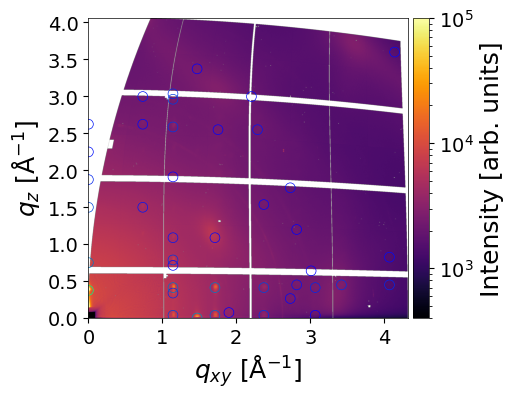

In [3]:
crystal = {
    'path_to_cif': cif_path_peaks,
    'orientation': [0,0,1],
    'min_int': 1e-3,
}

analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    crystal=crystal,
    plot_result=True,             # Display simulation overlay
    clims=(4e2,1e5),              # Intensity limits
)

---
## Crystal Description Dictionary
`crystal` is a dictionary that defines a single crystal for simulation and plotting in GIWAXS workflows. Each key controls either the crystal structure, orientation, intensity filtering, or optional plotting parameters.


Keys Description:

- `path_to_cif (str): Path to the CIF file containing the crystal structure.
- `orientation` (array-like [u, v, w] or str "random"): Crystal orientation (contact plane) in the laboratory frame.
- `min_int` (float): Minimum normalized intensity to include in the simulation/plot.

Optional Plotting Parameters:

- `cmap` (str): Colormap for intensity visualization.
- `vmin`, `vmax` (float): Colormap normalization limits.
- `marker` (str), `marker_size` (float): Style and size of plotted peaks.
- `line_width` (float), `line_style` (str): Line style for rings.
- `plot_mi` (bool): Whether to overlay Miller indices.
- `text_color` (str): Color of Miller indices.
- `text_size` (int): Size of Miller indices.

## Other parameters
- `return_result` – if `True`, returns a simulation result object.
- `save_fig` – if `True`, saves the resulting image.
- `path_to_save_fig` – filename for saving the image.
- `move_fromMW` – if `True`, moves reflections from the missing wedge to the border.
- `clims`, `xlim`, `ylim` - Color and axes limits for the figure.

---

## Single simulation example
### Oriented crystal

In [55]:
crystal_1 = {
    'path_to_cif': cif_path_peaks,
    'orientation': [0,0,1],  # 3x1 vector [u, v, w] or "random"
    'min_int': 1e-3,         # Minimum normalized intensity to include
    'cmap': 'winter',
    'plot_mi': False,
    'vmin': 0.01,
    'vmax': 1,
    'marker': 'o',
    'marker_size': 50,
    'line_width': 1,
    'line_style': "dashed",
    'text_color': "black"
}

INFO - Simulating GIWAXS data from CIF: /home/ainurabukaev/.cache/pygid/tutorial_09/DIP_thin_film_642482.cif, orientation: [0, 0, 1]


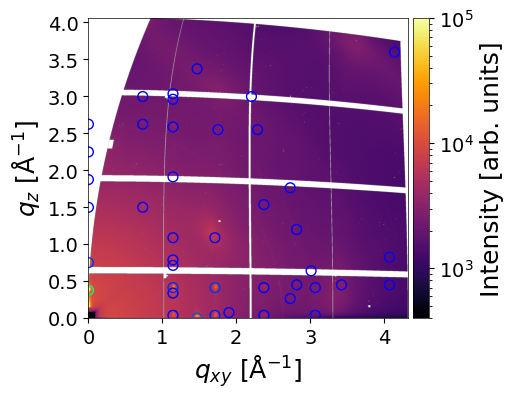

In [56]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    crystal = crystal_1,
    clims=(4e2,1e5),              # Color scale limits for experimental image
    plot_result=True,             # Display simulation overlay
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
)

The simulated peaks are visualized as circles, with colors proportional to their intensity. The color scale can be controlled using the `vmin` and `vmax` parameters, and the size of the circles can be adjusted with the `radius` parameter. When `return_result=True`, the function returns:

- `q_values` – a 2D array of peak positions (`q_xy`, `q_z`) (in Å⁻¹)
- `intensity` – array of simulated peak intensities
- `mi` – corresponding Miller indices for each peak

In [57]:
# results shape
q_values.shape, intensity.shape, mi.shape

((2, 42), (42,), (42, 3))

In [58]:
# split the q_values
q_xy = q_values[0]
q_z = q_values[1]

Peaks located in the missing wedge can be moved to the border by setting the `move_fromMW=True` flag:

INFO - Simulating GIWAXS data from CIF: /home/ainurabukaev/.cache/pygid/tutorial_09/DIP_thin_film_642482.cif, orientation: [0 0 1]


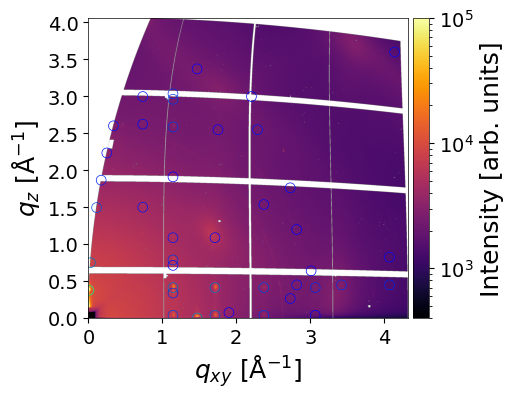

In [59]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    crystal = crystal,
    clims=(4e2,1e5),              # Color scale limits for experimental image
    plot_result=True,             # Display simulation overlay
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
    move_fromMW=True
)

### Random orientation

The `make_simulation()` function can also simulate and plot diffraction rings for randomly oriented crystals. To enable this, set `orientation` to `"random"`. The sharpness of the plotted rings can be controlled using the `linewidth` parameter.

When `return_result=True`, the function returns:

- `q_values` – a 1D array of absolute q-values (`q_abs`) (in Å⁻¹)
- `intensity` – array of simulated peak intensities
- `mi` – corresponding Miller indices for each peak


In [60]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_09")
    data_path = files["data_rings"]
    poni_path = files["poni_rings"]
    cif_path_rings = files["cif_rings"]
except:
    print("Dataset download skipped on Read the Docs.")

In [61]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=False,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params,  # pygid.ExpParams
    hor_positive=True,
    vert_positive=True
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
)

In [62]:
crystal_2 = {
    'path_to_cif': cif_path_rings,
    'orientation': "random",  # 3x1 vector [u, v, w] or "random"
    'min_int': 1e-5,         # Minimum normalized intensity to include
    'cmap': 'jet',
    'plot_mi': False,
    'vmin': 0.01,
    'vmax': 1,
    'line_width': 1,
    'line_style': "dashed",
    'text_color': "black"
}

INFO - Simulating GIWAXS data from CIF: /home/ainurabukaev/.cache/pygid/tutorial_09/MAPBTI02 - stoumpos_cubicMAPbI3.cif, orientation: random


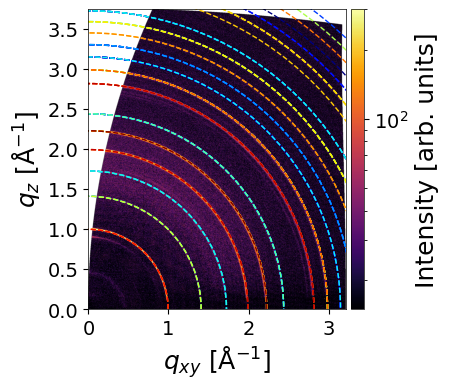

In [63]:
q_values, intensity, mi = analysis.make_simulation(
    frame_num=0,                  # Frame of experimental data
    crystal = crystal_2,
    clims=(15,300),              # Color scale limits for experimental image
    plot_result=True,             # Display simulation overlay
    plot_mi=False,                # Annotate peaks with Miller indices
    return_result=True,           # Return simulation result
    move_fromMW=True
)

The rings and arcs observed at 0.45, 0.51, and 0.65 Å⁻¹ are not simulated, as they originate from a Pb₃I₈ intermediate complex.


### Crystal description
To calculate a GIWAXS pattern from the own description instead of the CIF file, use the following example from [pygidSIM](https://github.com/mlgid-project/pygidSIM) description:

In [64]:
import numpy as np

# space group number
spgr = 221  # alternatively, use e.g. '146:R'

# lattice parameters [a, b, c, α, β, γ]
lat_par = np.array([6.3026, 6.3026, 6.3026, 90., 90., 90.], dtype=np.float32)

# list of atoms
atoms = np.array(['Pb', 'I', 'I', 'I', 'N'])

# relative atom positions
atom_positions = np.array(
    [[0., 0., 0.],
     [0.5, 0., 0.],
     [0., 0.5, 0.],
     [0., 0., 0.5],
     [0.5, 0.5, 0.5]], dtype=np.float32
)

# occupancies of the corresponding sites
occupancy = np.array([1., 1., 1., 1., 1.], dtype=np.float32)

crystal_3 = {
    'spgr': 221,
    'lat_par': lat_par,
    'atoms': atoms,
    'atom_positions': atom_positions,
    'occupancy': occupancy,
    'orientation': [0,0,1],
    'min_int': 0.002,
    'cmap': 'gray',
    'plot_mi': False,
    'vmin': 0.1,
    'vmax': 1,
    'marker': 'o',
    'marker_size': 50,
    'line_width': 1,
    'line_style': "dashed",
    'text_color': "black"
}

## Multiple Simulations

To plot multiple simulated patterns from different crystal or orientations, `make_simulation()` accepts **lists** for the dictionaries as crystal parameter:

When `return_result=True`, the function returns list of tuple for each crystal:

INFO - Simulating GIWAXS data from CIF: /home/ainurabukaev/.cache/pygid/tutorial_09/MAPBTI02 - stoumpos_cubicMAPbI3.cif, orientation: random
INFO - Simulating GIWAXS data from Crystal, orientation: [0, 0, 1]
INFO - Use already converted image with frame num 0


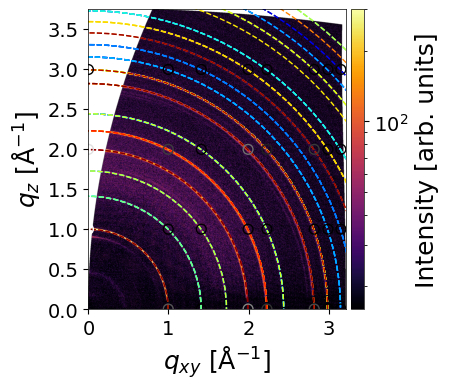

In [65]:
result_list = analysis.make_simulation(
    frame_num=0,
    clims=(16,300),
    crystal=[crystal_2, crystal_3],         # List of CIFs
    plot_result=True,
    plot_mi=False,
    return_result=True,
)

`result_list` is a list of tuples: `q_values, intensity, mi`:

In [66]:
len(result_list)

2